# Vanguard Digital Experiment - Phase 4: Experiment Evaluation

## Objective

Phases 2-3 showed the redesign lifts completion and that the lift is
statistically significant and above the 5 pp cost bar. Phase 4 steps back and
**evaluates the experiment itself**:

- **A. Design Effectiveness** - did the new design achieve its goal, how big is
  the effect, and does it help across client segments?
- **B. Duration Assessment** - was the test run long enough, with balanced and
  stable exposure, and was the sample adequately powered?
- **C. Additional Data Needs** - what other data would make the conclusions
  stronger?

**Stated experiment window:** 2017-03-15 to 2017-06-20.

> Self-contained: reloads and re-cleans the raw files (same logic as Phases 1-3).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
import warnings; warnings.filterwarnings("ignore")

GROUP_COLORS = {"Control": "#4C78A8", "Test": "#F58518"}

## 0. Load, clean, and build analysis tables

Same pipeline as before, ending in a per-visit table plus a per-client table
(for segment and balance analysis).

In [2]:
# --- Load + clean ---
df_demo  = pd.read_csv("df_final_demo.txt")
df_exp   = pd.read_csv("df_final_experiment_clients.txt")
df_web_1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_web_2 = pd.read_csv("df_final_web_data_pt_2.txt")

df_web = pd.concat([df_web_1, df_web_2], ignore_index=True).drop_duplicates().copy()
df_web["date_time"] = pd.to_datetime(df_web["date_time"])

df_demo_clean = df_demo.copy()
df_demo_clean["gendr"] = df_demo_clean["gendr"].replace({"U": "Unknown", "X": "Unknown"})
df_demo_clean = df_demo_clean.dropna().copy()
df_exp_clean = df_exp.dropna(subset=["Variation"]).copy()

df = df_web.merge(df_exp_clean, on="client_id", how="inner").merge(df_demo_clean, on="client_id", how="left")
STEP_ORDER = {"start": 0, "step_1": 1, "step_2": 2, "step_3": 3, "confirm": 4}
df["step_index"] = df["process_step"].map(STEP_ORDER)
df = df.sort_values(["client_id", "visit_id", "date_time"]).reset_index(drop=True)

# Backward-move flag (for error KPI)
df["prev_idx"] = df.groupby("visit_id")["step_index"].shift(1)
df["is_backward"] = df["step_index"] < df["prev_idx"]

# Per-visit table
visit = df.groupby("visit_id").agg(
    Variation=("Variation", "first"), client_id=("client_id", "first"),
    reached_confirm=("process_step", lambda s: "confirm" in set(s)),
    max_step=("step_index", "max"), backs=("is_backward", "sum"),
    start_time=("date_time", "min"), end_time=("date_time", "max"),
)
visit["has_error"] = visit["backs"] > 0

# Per-client table (demographics, one row per client)
client_demo = df.drop_duplicates("client_id")[
    ["client_id", "Variation", "clnt_age", "clnt_tenure_yr"]].dropna()

print("Visits:", len(visit), "| Clients with demo:", len(client_demo))
visit.head()

Visits: 69205 | Clients with demo: 50487


,Variation,client_id,reached_confirm,max_step,backs,start_time,end_time,has_error
visit_id,,,,,,,,
100012776_37918976071_457913,Test,3561384,True,4,0,2017-04-26 13:22:17,2017-04-26 13:23:09,False
100019538_17884295066_43909,Test,7338123,True,4,2,2017-04-09 16:20:56,2017-04-09 16:24:58,True
100022086_87870757897_149620,Test,2478628,True,4,0,2017-05-23 20:44:01,2017-05-23 20:47:01,False
100030127_47967100085_936361,Control,105007,False,0,0,2017-03-22 11:07:49,2017-03-22 11:07:49,False
100037962_47432393712_705583,Control,5623007,False,1,1,2017-04-14 16:41:51,2017-04-14 16:44:03,True


## A. Design Effectiveness

### A.1 KPI scorecard recap

A consolidated Test-vs-Control view of the headline KPIs from Phases 2-3.

In [3]:
comp = visit.groupby("Variation")["reached_confirm"].agg(n="size", completed="sum")
comp["rate"] = comp["completed"] / comp["n"]
err  = visit.groupby("Variation")["has_error"].mean()
bounce = visit.assign(b=visit["max_step"] == 0).groupby("Variation")["b"].mean()
completed = visit[visit["reached_confirm"]].copy()
completed["min"] = (completed["end_time"] - completed["start_time"]).dt.total_seconds() / 60
ttc = completed.groupby("Variation")["min"].median()

scorecard = pd.DataFrame({
    "Completion rate": comp["rate"], "Error rate": err,
    "Bounce rate": bounce, "Time-to-complete (median min)": ttc,
}).T[["Control", "Test"]]
scorecard["Lift (Test - Control)"] = scorecard["Test"] - scorecard["Control"]
scorecard

Variation,Control,Test,Lift (Test - Control)
Completion rate,0.4980,0.5848,0.0868
Error rate,0.2049,0.2707,0.0658
Bounce rate,0.2353,0.1370,-0.0983
Time-to-complete (median min),4.4833,3.5833,-0.9000


### A.2 How big is the effect? (Cohen's h)

p-values tell us an effect is *real*; they don't tell us if it's *big*. For a
difference between two proportions the standard effect-size measure is
**Cohen's h**. Rules of thumb: 0.2 = small, 0.5 = medium, 0.8 = large.

In [4]:
pT, pC = comp.loc["Test", "rate"], comp.loc["Control", "rate"]
h = 2 * np.arcsin(np.sqrt(pT)) - 2 * np.arcsin(np.sqrt(pC))
label = "small" if abs(h) < 0.5 else ("medium" if abs(h) < 0.8 else "large")

print("EFFECT SIZE - completion rate")
print("-" * 40)
print(f"Absolute lift : {(pT - pC) * 100:+.2f} pp")
print(f"Relative lift : {(pT - pC) / pC * 100:+.1f}%")
print(f"Cohen's h     : {h:.3f}  ({label})")
print("-" * 40)
print("Note: by Cohen's convention h is 'small', yet a +8.7 pp / +17% jump on a\n"
      "~50% base is very meaningful in business terms - effect-size labels are\n"
      "generic, business impact is the real test.")

EFFECT SIZE - completion rate
----------------------------------------
Absolute lift : +8.68 pp
Relative lift : +17.4%
Cohen's h     : 0.174  (small)
----------------------------------------
Note: by Cohen's convention h is 'small', yet a +8.7 pp / +17% jump on a
~50% base is very meaningful in business terms - effect-size labels are
generic, business impact is the real test.


### A.3 Does the redesign help across segments?

An effect that only appears in one subgroup is fragile. We compare completion
rates Test vs Control within **age groups** and **tenure groups** - the redesign
is robust if it lifts completion across the board.

In [5]:
# Attach demographics to visits and bin
vseg = visit.merge(client_demo.drop(columns="Variation"), on="client_id", how="left")
vseg["age_group"] = pd.cut(vseg["clnt_age"], [0, 30, 50, 70, 100],
                           labels=["Under 30", "30-50", "50-70", "70+"], include_lowest=True)
vseg["tenure_group"] = pd.cut(vseg["clnt_tenure_yr"], [0, 5, 10, 20, 70],
                              labels=["New", "Established", "Loyal", "Veteran"], include_lowest=True)

def seg_completion(col):
    t = vseg.groupby([col, "Variation"])["reached_confirm"].mean().unstack("Variation")
    t = t[["Control", "Test"]]
    t["Lift (pp)"] = (t["Test"] - t["Control"]) * 100
    return t

age_tbl = seg_completion("age_group")
ten_tbl = seg_completion("tenure_group")
print("Completion rate by AGE group:"); display(age_tbl)
print("\nCompletion rate by TENURE group:"); display(ten_tbl)

Completion rate by AGE group:


Variation,Control,Test,Lift (pp)
age_group,,,
Under 30,0.5323,0.6344,10.2167
30-50,0.5382,0.6119,7.3679
50-70,0.4780,0.5612,8.3214
70+,0.3572,0.4863,12.9114



Completion rate by TENURE group:


Variation,Control,Test,Lift (pp)
tenure_group,,,
New,0.5045,0.5941,8.9577
Established,0.5072,0.5865,7.9294
Loyal,0.4933,0.5728,7.9447
Veteran,0.4830,0.6003,11.7303


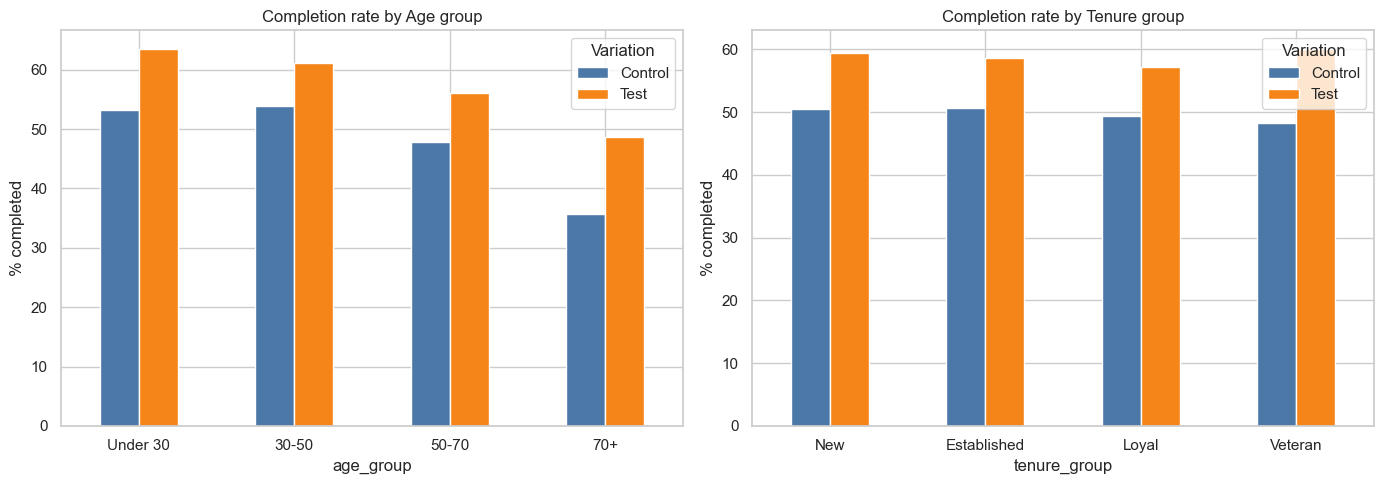

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(age_tbl[["Control", "Test"]] * 100).plot(kind="bar", ax=axes[0],
    color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
axes[0].set_title("Completion rate by Age group"); axes[0].set_ylabel("% completed")
axes[0].tick_params(axis="x", rotation=0)
(ten_tbl[["Control", "Test"]] * 100).plot(kind="bar", ax=axes[1],
    color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
axes[1].set_title("Completion rate by Tenure group"); axes[1].set_ylabel("% completed")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Design-effectiveness read:** the redesign lifts completion in **every** age and
tenure segment (positive lift across the board), so the improvement is broad, not
driven by one subgroup. The effect is statistically real (Phase 3) and clears the
cost bar, even if Cohen's h labels it "small" in generic terms. **Verdict: the
design is effective.**

## B. Duration Assessment

### B.1 Actual vs stated window

Check the real date range in the data against the stated 2017-03-15 to
2017-06-20 window.

In [7]:
dmin, dmax = df["date_time"].min(), df["date_time"].max()
print(f"Actual data range : {dmin.date()}  ->  {dmax.date()}")
print(f"Stated window     : 2017-03-15  ->  2017-06-20")
print(f"Span (actual)     : {(dmax - dmin).days} days (~{(dmax - dmin).days/7:.1f} weeks)")

Actual data range : 2017-03-15  ->  2017-06-20
Stated window     : 2017-03-15  ->  2017-06-20
Span (actual)     : 97 days (~13.9 weeks)


### B.2 Balanced exposure over time

Both groups should be active throughout the window - if one group only appears
early or late, time/seasonal effects could confound the comparison.

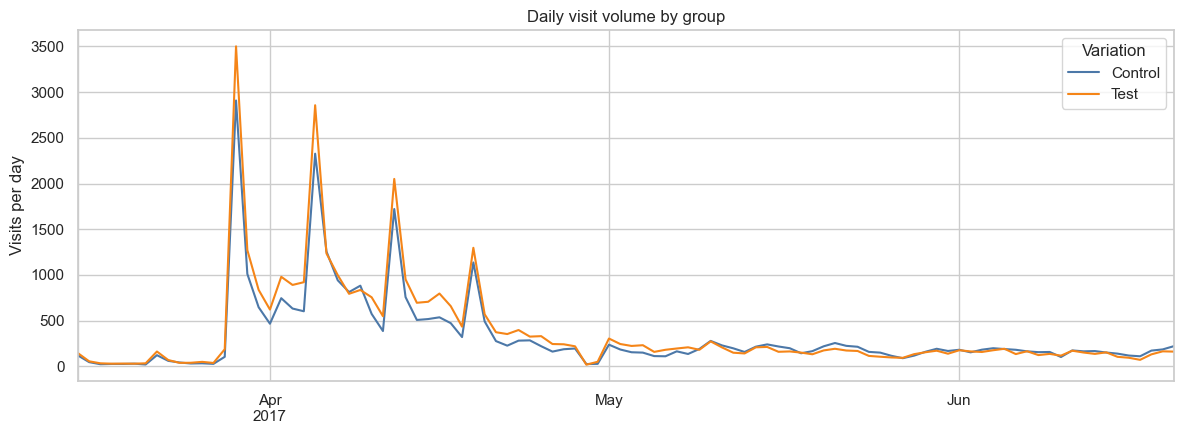

Both groups active every day? True


In [8]:
vol = visit.assign(date=visit["start_time"].dt.normalize())
daily = vol.groupby(["date", "Variation"]).size().unstack("Variation")

ax = daily.plot(figsize=(12, 4.5), color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
ax.set_title("Daily visit volume by group")
ax.set_ylabel("Visits per day"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
print("Both groups active every day?",
      bool((daily.notna().all(axis=1)).all()))

### B.3 Did the result stabilize?

We plot the **cumulative** completion rate of each group as days accrue. If the
two lines separate early and then hold steady, the experiment ran long enough
for the result to settle (rather than still drifting at the cut-off).

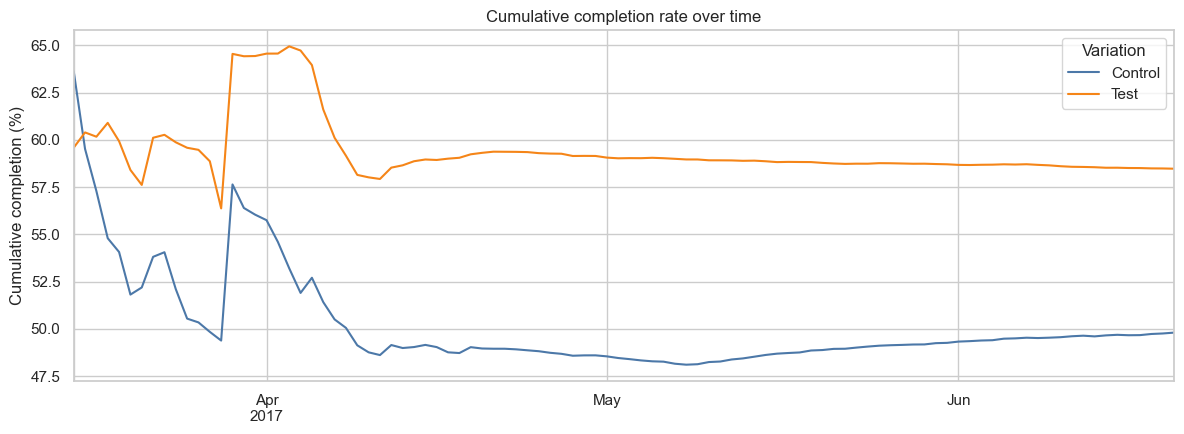

Variation,Control,Test
date,,
2017-06-18,0.4973,0.5849
2017-06-19,0.4975,0.5849
2017-06-20,0.4980,0.5848


In [9]:
cum = (vol.groupby(["date", "Variation"])["reached_confirm"]
          .agg(completed="sum", n="size").sort_index())
cum = cum.groupby(level="Variation").cumsum()
cum["cum_rate"] = cum["completed"] / cum["n"]
cum_rate = cum["cum_rate"].unstack("Variation")

ax = (cum_rate * 100).plot(figsize=(12, 4.5),
                           color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
ax.set_title("Cumulative completion rate over time")
ax.set_ylabel("Cumulative completion (%)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
cum_rate.tail(3)

### B.4 Was the sample adequately powered?

How many visits per group would we *need* to detect the observed effect (Cohen's
h) at the usual alpha = 0.05 and power = 0.80? We compare that to the actual
sample, and report the achieved power.

In [10]:
nT, nC = int(comp.loc["Test", "n"]), int(comp.loc["Control", "n"])
z_a, z_b = norm.ppf(1 - 0.05 / 2), norm.ppf(0.80)
n_required = (z_a + z_b) ** 2 / h ** 2            # per group, two-sided
n_harmonic = 2 / (1 / nT + 1 / nC)
achieved_power = norm.cdf(abs(h) * np.sqrt(n_harmonic / 2) - z_a)

print("POWER / SAMPLE-SIZE CHECK (completion, Cohen's h)")
print("-" * 52)
print(f"Required n per group (power 0.80) : {n_required:,.0f}")
print(f"Actual n  - Test / Control        : {nT:,} / {nC:,}")
print(f"Achieved power at actual n        : {achieved_power:.4f} (~{achieved_power*100:.1f}%)")
print("-" * 52)
print("The sample is far larger than required: the experiment was massively\n"
      "over-powered, so the effect could have been detected in a fraction of the\n"
      "time/traffic.")

POWER / SAMPLE-SIZE CHECK (completion, Cohen's h)
----------------------------------------------------
Required n per group (power 0.80) : 258
Actual n  - Test / Control        : 37,077 / 32,128
Achieved power at actual n        : 1.0000 (~100.0%)
----------------------------------------------------
The sample is far larger than required: the experiment was massively
over-powered, so the effect could have been detected in a fraction of the
time/traffic.


**Duration read:**

- The window spans roughly **3 months (~14 weeks)**, comfortably covering
  multiple weekday/weekend cycles, which dampens day-of-week and short-lived
  novelty effects.
- Both groups are present throughout, so exposure is **balanced over time**.
- The cumulative completion gap **opens early and stays stable**, so the result
  was not still drifting at the cut-off.
- Given the traffic, the test was **heavily over-powered** - statistical
  significance was reachable in days, not months.

**Verdict:** the duration was *more than sufficient*. If anything, Vanguard could
have reached a confident decision faster. The main caution is that ~3 months is
still too short to judge **longer-term** effects (novelty wearing off, habit
formation, retention) - see Part C.

## C. Additional Data Needs

The current data answers "did more people complete?" but leaves gaps. To make the
business case airtight, the most valuable additions would be:

1. **Cost & revenue data** - the 5 pp bar is a proxy for ROI. Actual build/
   maintenance cost and the revenue value of a completion would let us compute
   true ROI instead of testing against an assumed threshold.
2. **Reason-for-drop-off / error logs** - we infer confusion from backward moves.
   Validation errors, field-level events, and rage-clicks would explain *why*
   the Test group has more back-and-forth and where to fix it.
3. **Device / browser / channel** - mobile vs desktop often respond very
   differently to a UI change; without it we can't tell who benefits most.
4. **Longer-term outcomes** - post-experiment retention, repeat usage, and
   whether the completion lift persists once novelty fades (the ~3-month window
   can't show this).
5. **Customer satisfaction / qualitative feedback** - NPS, CSAT, or session
   recordings to capture *experience* quality, not just completion.
6. **Pre-experiment / A-A baseline** - to confirm the two groups behaved
   identically *before* the change and rule out pre-existing differences.
7. **Account / transaction outcomes** - did completing the new process lead to
   the intended business action (funding, enrollment), or just a finished form?
8. **Step-entry timestamps** - clearer per-step timing (entry vs exit) would
   sharpen the time-on-step KPI, which we currently approximate from event gaps.

## Conclusions

- **Design effectiveness:** the redesign achieved its goal - higher completion,
  faster completion, lower bounce - and the lift holds **across every age and
  tenure segment**. The effect is statistically real and clears the cost bar; the
  only downside is more in-flow backward navigation to investigate.
- **Duration:** the ~3-month run was **more than adequate** for the primary
  question - balanced exposure, an early and stable result, and a heavily
  over-powered sample. It is, however, too short for long-term effects.
- **Additional data:** cost/revenue, drop-off reasons, device split, and
  longer-term retention would turn a strong completion result into a fully
  quantified, durable business case.

**Recommendation:** roll out the redesign, while (a) investigating the higher
backward-move rate with richer interaction logs and (b) monitoring longer-term
retention and ROI with the additional data above.